In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import ks_2samp

In [5]:
x_train=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\x_train.txt",sep=" ")
x_test=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\x_test.txt",sep=" ")
y_train=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\y_train.txt")

In [6]:
train=pd.concat([x_train,y_train],axis=1)

In [22]:
train_true=train[train.iloc[:,500]==1]
train_false=train[train.iloc[:,500]==0]


In [25]:
x_train_true=train_true.iloc[:,:-1]
x_train_false=train_false.iloc[:,:-1]

In [7]:
corr_matrix = train.corr()


In [20]:
np.sum(y_train)

np.int64(2488)

In [10]:
target_col_name = train.columns[-1]

target_corr = corr_matrix[target_col_name]

target_corr = target_corr.drop(labels=[target_col_name])

threshold = 0.1
relevant_features = target_corr[target_corr.abs() > threshold].sort_values(ascending=False)
print(len(relevant_features))
print(relevant_features)

6
V390    0.113968
V224    0.109128
V161    0.105698
V32     0.103328
V175    0.103328
V11     0.101000
Name: y, dtype: float64


In [12]:
def check_distribution_drift(df_train, df_test, threshold=0.05):
    drift_results = []

    for column in df_train.columns:
        stat, p_value = ks_2samp(df_train[column], df_test[column])
        if p_value < threshold:
            drift_results.append({
                'column': column,
                'p_value': p_value,
                'status': 'Different'
            })

    return pd.DataFrame(drift_results)

drifted_features = check_distribution_drift(x_train, x_test)
print(f"Number of drifted features: {len(drifted_features)}")

Number of drifted features: 26


In [26]:
features_with_different_distributions=check_distribution_drift(x_train_true,x_train_false)
print(f"Number of features with different distributions: {len(features_with_different_distributions)}")


Number of features with different distributions: 53


In [27]:
print(features_with_different_distributions)

   column       p_value     status
0      V3  1.846829e-02  Different
1      V5  1.274071e-04  Different
2      V6  1.423363e-02  Different
3     V11  3.353528e-13  Different
4     V32  7.772217e-09  Different
5     V46  1.850615e-08  Different
6     V55  3.808463e-02  Different
7     V60  5.257798e-08  Different
8     V72  4.401267e-02  Different
9     V78  6.492445e-03  Different
10   V117  1.399290e-04  Different
11   V120  8.748540e-05  Different
12   V127  2.755529e-02  Different
13   V146  2.175956e-02  Different
14   V160  1.477014e-06  Different
15   V161  1.867617e-11  Different
16   V175  7.772217e-09  Different
17   V176  3.002991e-12  Different
18   V179  1.920802e-02  Different
19   V185  2.269521e-02  Different
20   V191  5.128255e-11  Different
21   V198  4.622830e-02  Different
22   V199  4.634870e-08  Different
23   V215  2.973166e-04  Different
24   V221  3.637237e-02  Different
25   V224  3.263676e-13  Different
26   V227  1.348586e-02  Different
27   V255  3.286481e

In [13]:
print(drifted_features)

   column   p_value     status
0      V9  0.013569  Different
1     V24  0.008079  Different
2     V29  0.026547  Different
3     V54  0.039677  Different
4     V55  0.017417  Different
5     V96  0.010504  Different
6    V107  0.011948  Different
7    V119  0.020915  Different
8    V141  0.003537  Different
9    V143  0.049482  Different
10   V148  0.035444  Different
11   V163  0.035444  Different
12   V190  0.035444  Different
13   V242  0.019685  Different
14   V249  0.049482  Different
15   V254  0.006174  Different
16   V276  0.015385  Different
17   V303  0.004688  Different
18   V307  0.029836  Different
19   V325  0.011205  Different
20   V326  0.022213  Different
21   V346  0.006607  Different
22   V453  0.035444  Different
23   V455  0.026547  Different
24   V477  0.014451  Different
25   V498  0.014451  Different


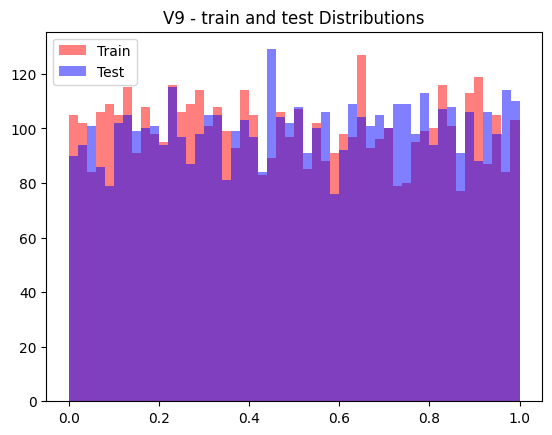

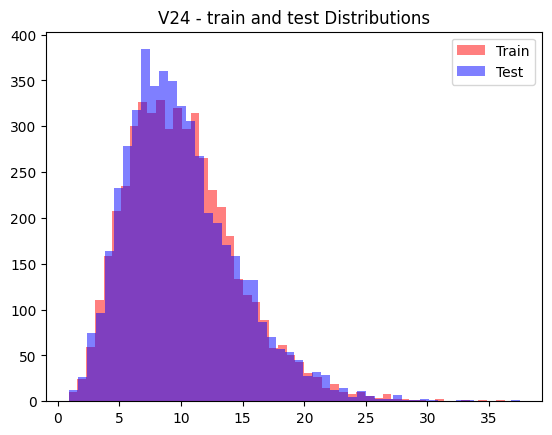

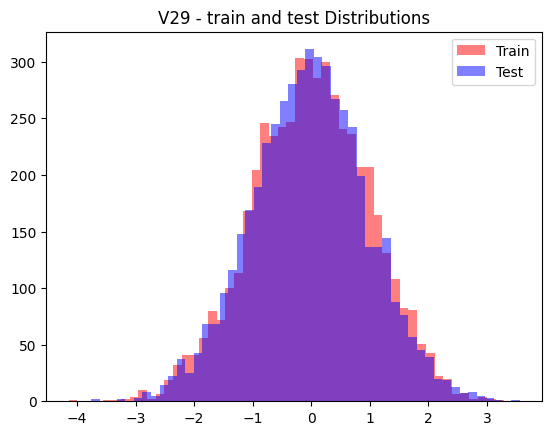

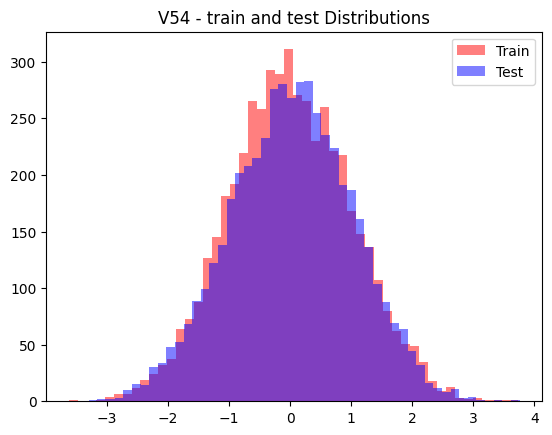

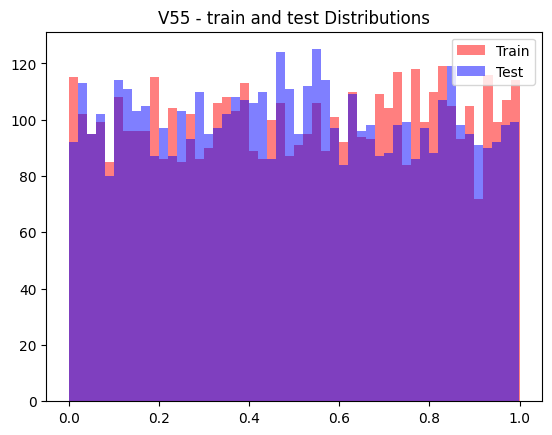

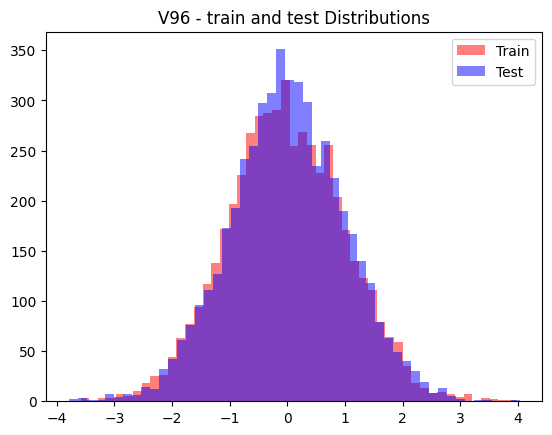

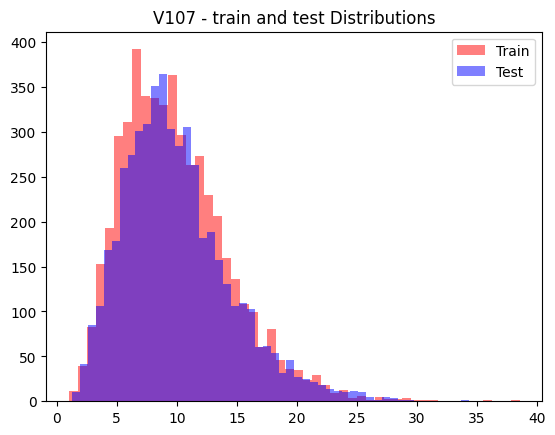

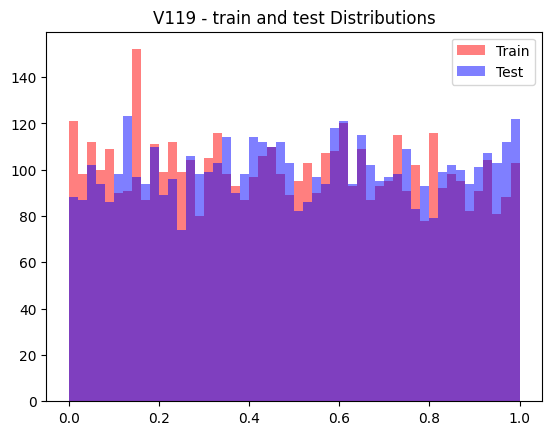

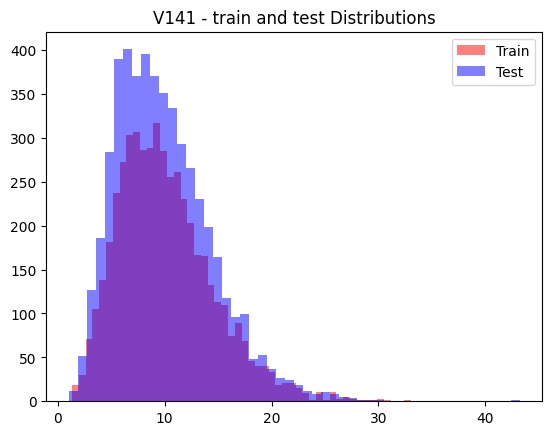

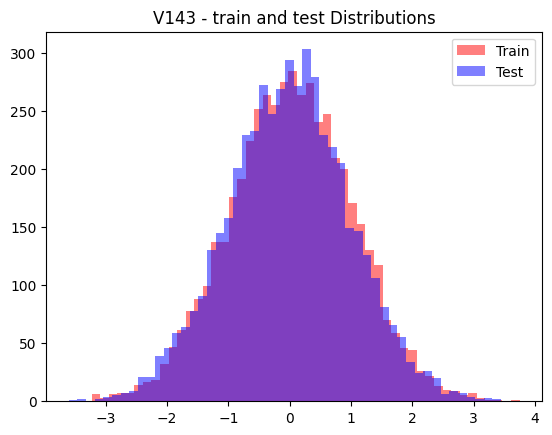

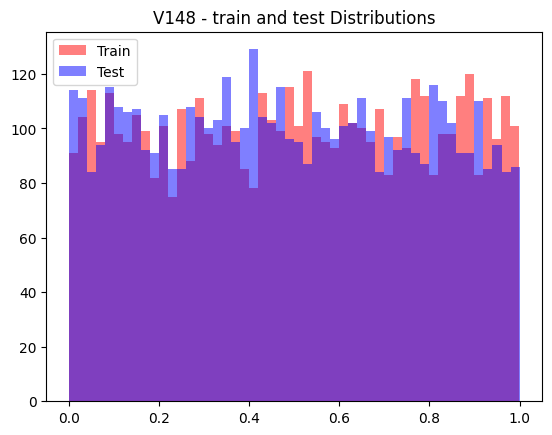

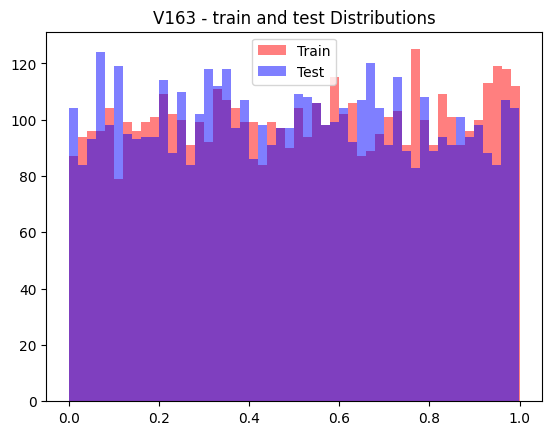

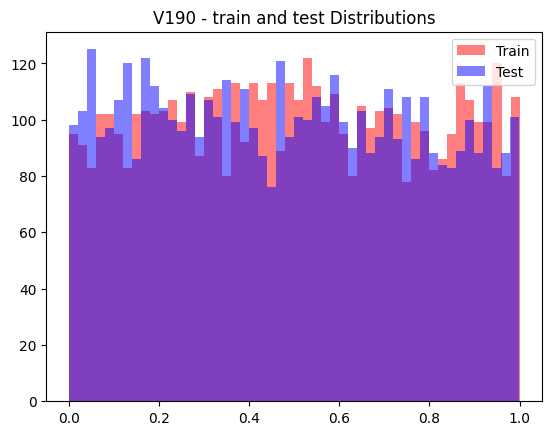

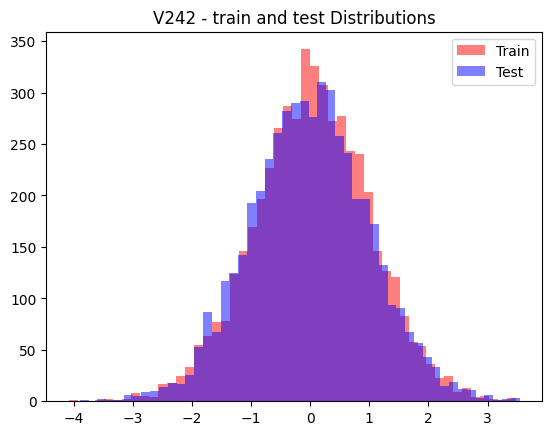

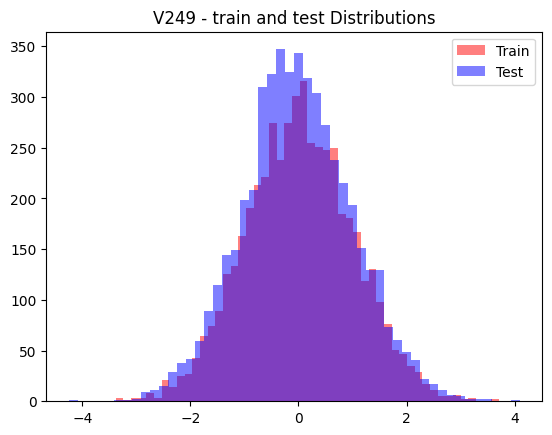

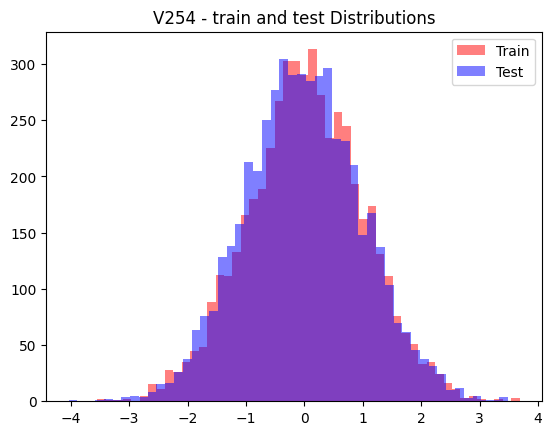

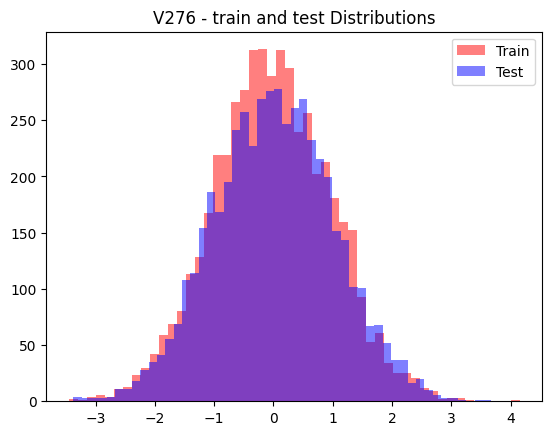

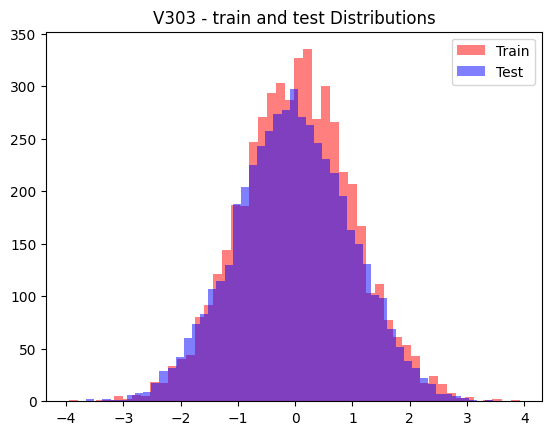

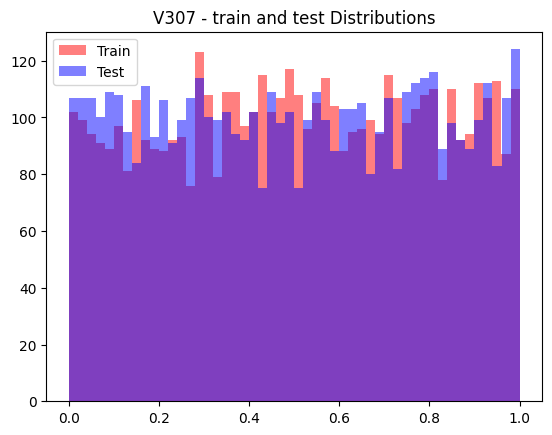

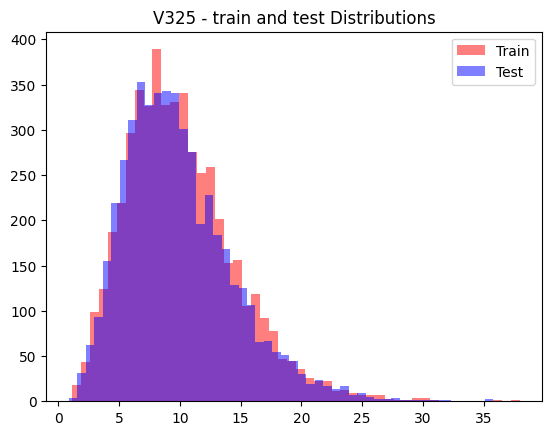

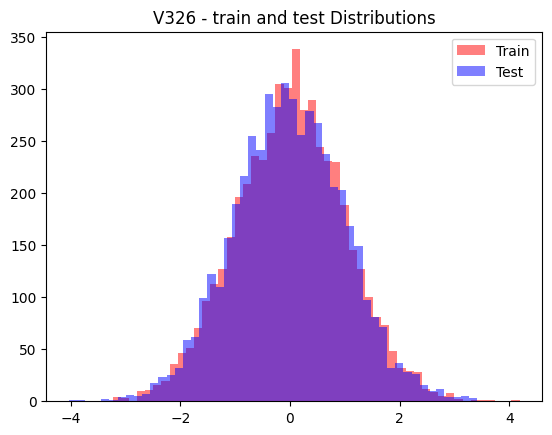

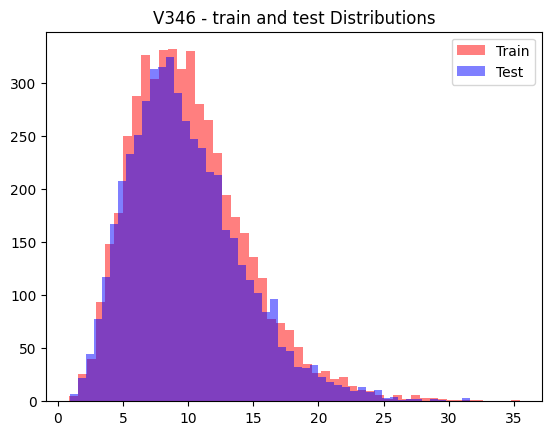

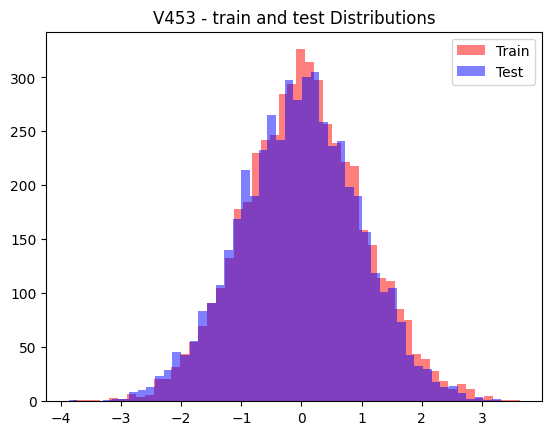

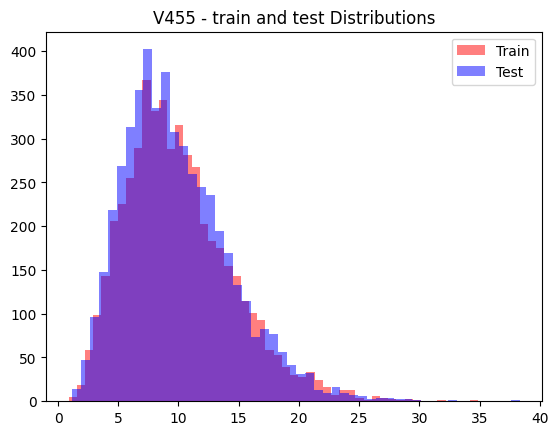

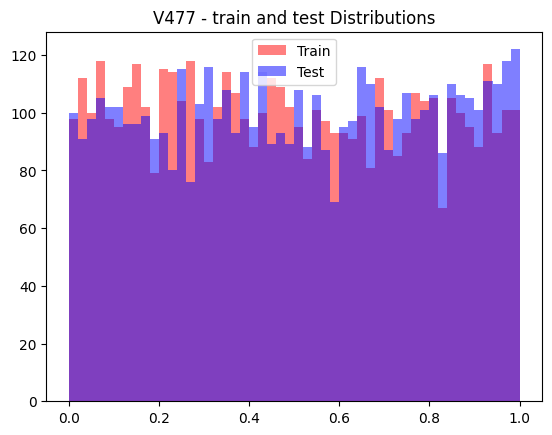

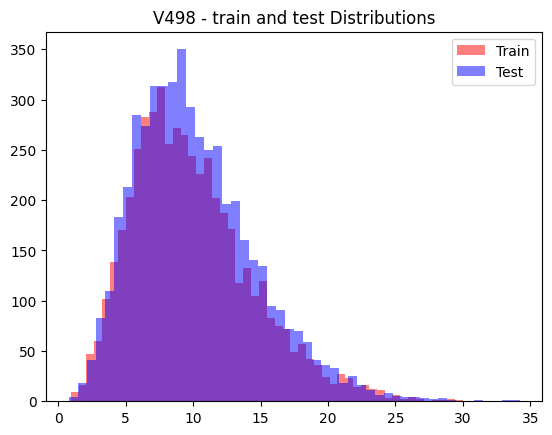

In [17]:
for i in range(len(drifted_features)):
    col_name = drifted_features.iloc[i]['column']
    plt.hist(x_train[col_name], bins=50, color='red', alpha=0.5, label='Train')
    plt.hist(x_test[col_name], bins=50, color='blue', alpha=0.5, label='Test')
    plt.legend()
    plt.title(f"{col_name} - train and test Distributions")
    plt.show()